<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 18 - Ejemplo 1 - Métodos de ensamble
        </td>
    </tr>
    <tr>
 

</table>

Una institución financiera desea implementar un sistema automático para apoyar la detección de billetes auténticos y falsificados. Para ello, se cuenta con un conjunto de datos compuesto por 1372 observaciones, donde cada registro representa un billete analizado mediante técnicas de procesamiento de imágenes.

El dataset contiene cuatro variables predictoras numéricas obtenidas a partir de características estadísticas de la imagen del billete:

- Variance: varianza de la imagen transformada.
- Skewness: asimetría de la imagen transformada.
- Curtosis: curtosis de la imagen transformada.
- Entropy: entropía de la imagen.

La variable objetivo es:

- Class: indica la clase del billete, donde:
  - 0 representa un billete auténtico.
  - 1 representa un billete falsificado.

Realizar un modelo de ensamble de árboles de decisión para las variables Varianza y Curtosis  donde se agrupen 500 modelos predictores
entrenados con 100 observaciones de la muestra de entrenamiento cada uno. Para
poder validar el modelo, dividir el conjunto de datos en 20% para la validación.

a) Realizar un árbol de decisión con los parámetros por defecto

b) Crear un modelo de emsable de árboles de dicisión reemplazamiento (bagging).

c) Sin reemplazamiento (pasting).

d) Realizando Random Forest (fijando el número de nodos hoja máximo a 16).

e) Ajustar el mismo modelo pero empleando Gradient Boosting

In [1]:
import numpy as np
import pandas as pd
import array
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
from array import*
import scipy.stats as stats
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import os, sys

In [2]:
datos = pd.read_csv("bill_authentication.csv")

In [3]:
datos

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [4]:
X_independientes = datos[["Variance", "Curtosis"]]
y_dependiente = datos["Class"]

<Figure size 640x480 with 0 Axes>

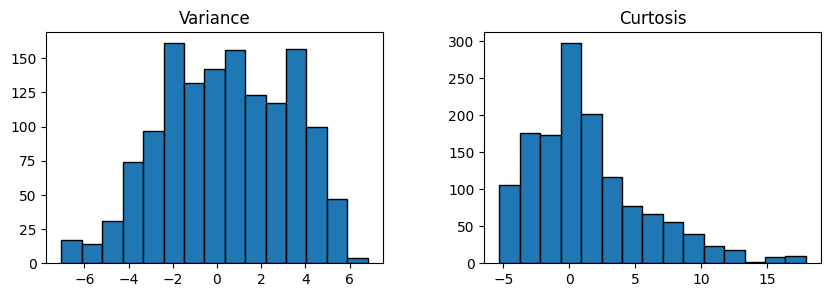

In [5]:
plt.figure()
X_independientes.hist(figsize=(10,3), edgecolor="black", bins=15, grid=False)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_independientes, y_dependiente, test_size=0.20, random_state=2026)

In [7]:
X_train

,Variance,Curtosis
1317,-1.266700,-2.42600
414,1.981800,-3.52100
1138,-2.596100,9.79420
1075,0.376370,0.78543
1367,0.406140,-1.45010
...,...,...
333,3.000900,-2.23060
77,0.049175,1.78280
952,-1.284600,-1.76710
794,-1.624400,4.65750


In [8]:
from sklearn.tree import DecisionTreeClassifier

#Crear el objeto de clase árbol con los parámetros por defecto
tree_clf = DecisionTreeClassifier(random_state = 2026)
#Ajustar el arbol
tree_clf.fit(X_train, y_train);

In [9]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_a = tree_clf.predict(X_test)
accuracy_a = accuracy_score(y_test, y_pred_a)
print("El accuracy score que se tiene es %s" %accuracy_a)

El accuracy score que se tiene es 0.8472727272727273


Text(50.722222222222214, 0.5, 'Real')

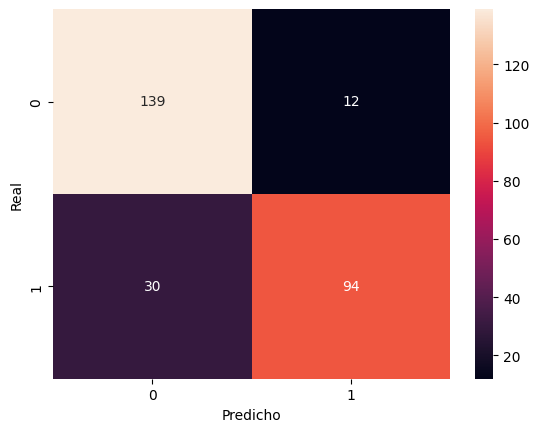

In [10]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_1 = precision_score(y_test, y_pred_a)
recall_1 = recall_score(y_test, y_pred_a)
f1_1 = f1_score(y_test, y_pred_a)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_1, recall_1,f1_1]})
metricas

,Métricas,Valores
0,Precisión,0.886792
1,Recall,0.758065
2,F1,0.817391


El árbol de decisión con parámetros por defecto obtuvo un accuracy de 0.8473, lo que indica que el modelo clasificó correctamente el 84.73% de los billetes del conjunto de validación. Para la clase 1, correspondiente a billetes falsificados, se obtuvo una precisión de 0.8868, un recall de 0.7581 y un F1-score de 0.8174. Estos resultados muestran que el modelo tiene una buena capacidad para clasificar como falsificados los billetes que predice como tales; sin embargo, el recall indica que aún existe una proporción de billetes falsificados que no son detectados. Por tanto, este árbol puede considerarse un modelo base aceptable, aunque susceptible de mejora mediante métodos de ensamble.

In [12]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, alpha=0.5, contour=True):
    axes=[np.min(X.iloc[:, 0]), np.max(X.iloc[:, 0]), np.min(X.iloc[:, 1]), np.max(X.iloc[:, 1])]
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    plt.plot(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], "yo", alpha=alpha)
    plt.plot(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], "bs", alpha=alpha)
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


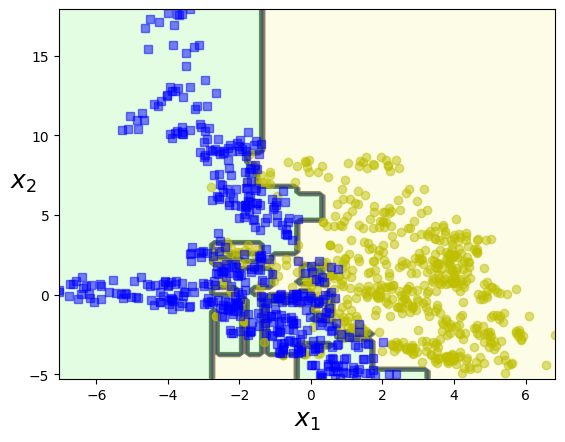

In [13]:
plot_decision_boundary(tree_clf, X_train, y_train, alpha=0.5, contour=True)

In [14]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier( DecisionTreeClassifier(), n_estimators=500, max_samples=100, bootstrap=True, random_state=2026)
bag_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",100
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",2026
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [15]:
#Obtener el accuracy_score
y_pred_bag = bag_clf.predict(X_test)
accuracy_bag = accuracy_score(y_test, y_pred_bag)
print("El accuracy score que se tiene es %s" %accuracy_bag)

El accuracy score que se tiene es 0.8981818181818182


Text(50.722222222222214, 0.5, 'Real')

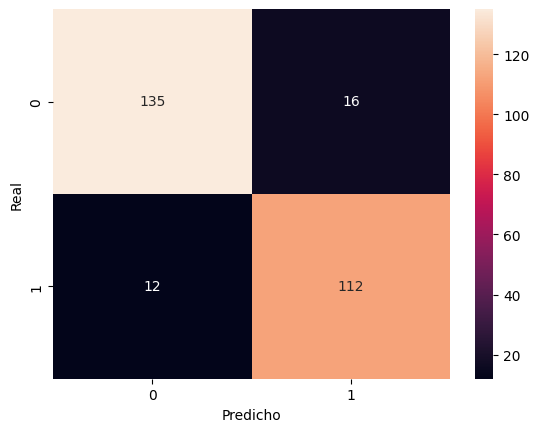

In [16]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_bag)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_1 = precision_score(y_test, y_pred_bag)
recall_1 = recall_score(y_test, y_pred_bag)
f1_1 = f1_score(y_test, y_pred_bag)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_1, recall_1,f1_1]})
metricas

,Métricas,Valores
0,Precisión,0.875000
1,Recall,0.903226
2,F1,0.888889


El modelo de bagging obtuvo un accuracy de 0.8982, clasificando correctamente el 89.82% de los billetes del conjunto de validación. Para la clase 1, correspondiente a billetes falsificados, se obtuvo una precisión de 0.8750, un recall de 0.9032 y un F1-score de 0.8889. Aunque la precisión disminuye ligeramente en comparación con el árbol de decisión individual, el recall aumenta de manera considerable, lo cual es especialmente importante en este problema, ya que permite detectar una mayor proporción de billetes falsificados. En consecuencia, el modelo de bagging presenta un mejor desempeño general que el árbol de decisión base.

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names


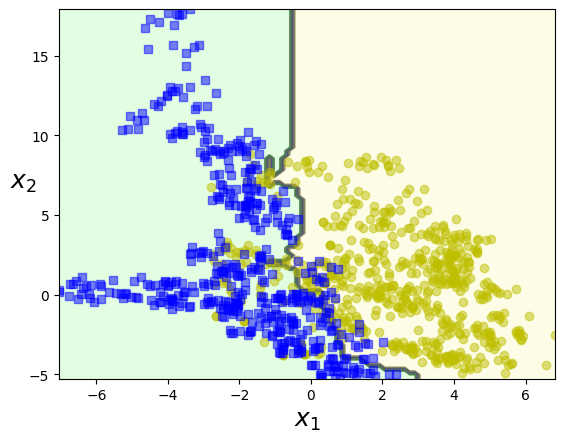

In [18]:
plot_decision_boundary(bag_clf, X_train, y_train, alpha=0.5, contour=True)

In [19]:
from sklearn.ensemble import BaggingClassifier

pas_clf = BaggingClassifier( DecisionTreeClassifier(), n_estimators=500, max_samples=100, bootstrap=False, random_state=2026)
pas_clf.fit(X_train, y_train)
y_pred = pas_clf.predict(X_test)

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names


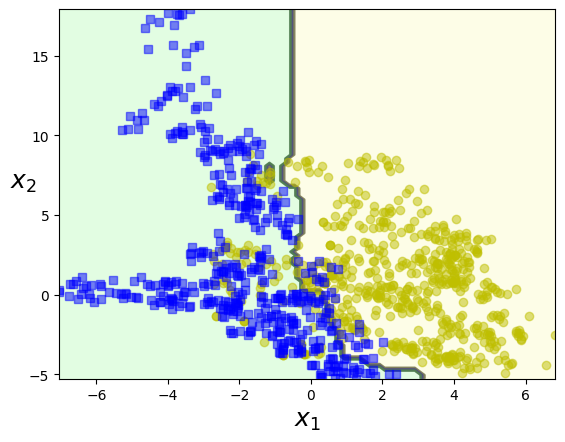

In [20]:
plot_decision_boundary(pas_clf, X_train, y_train, alpha=0.5, contour=True)

In [21]:
#Obtener el accuracy_score
y_pred_pas = pas_clf.predict(X_test)
accuracy_pas = accuracy_score(y_test, y_pred_pas)
print("El accuracy score que se tiene es %s" %accuracy_pas)

El accuracy score que se tiene es 0.8981818181818182


El accuracy score que se tiene es 0.8981818181818182


Text(50.722222222222214, 0.5, 'Real')

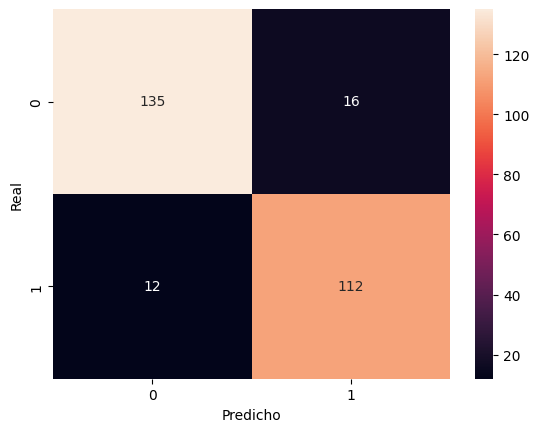

In [22]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_pas)
sns.heatmap(cm, annot=True, fmt="d")#Obtener el accuracy_score
y_pred_pas = pas_clf.predict(X_test)
accuracy_pas = accuracy_score(y_test, y_pred_pas)
print("El accuracy score que se tiene es %s" %accuracy_pas)
plt.xlabel("Predicho")
plt.ylabel("Real")

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_pas = precision_score(y_test, y_pred_pas)
recall_pas = recall_score(y_test, y_pred_pas)
f1_pas = f1_score(y_test, y_pred_pas)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_pas, recall_pas,f1_pas]})
metricas

,Métricas,Valores
0,Precisión,0.875000
1,Recall,0.903226
2,F1,0.888889


El modelo de pasting obtuvo las mismas métricas que el modelo de bagging, con un accuracy de 0.8982, precisión de 0.8750, recall de 0.9032 y F1-score de 0.8889. Este resultado es posible, ya que ambos métodos emplean múltiples árboles de decisión entrenados sobre subconjuntos de la muestra de entrenamiento. Aunque bagging utiliza muestreo con reemplazamiento y pasting muestreo sin reemplazamiento, en este caso ambos procedimientos generaron un comportamiento predictivo equivalente sobre el conjunto de validación. Por tanto, no se observó una diferencia práctica entre ambos métodos para esta partición de datos y esta configuración del modelo.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, random_state=2026)
rnd_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",16
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [25]:
#Obtener el accuracy_score
y_pred_rf = rnd_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("El accuracy score que se tiene es %s" %accuracy_rf)

El accuracy score que se tiene es 0.9054545454545454


Text(50.722222222222214, 0.5, 'Real')

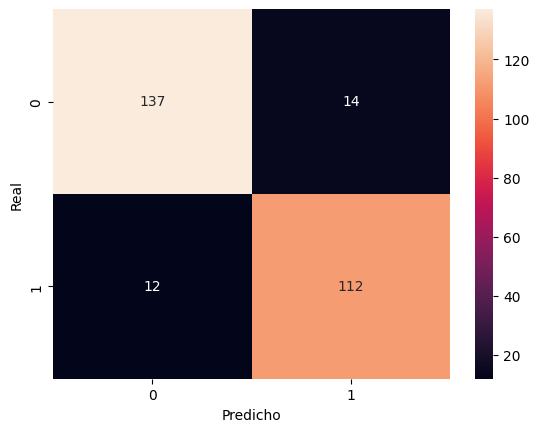

In [26]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_rf, recall_rf,f1_rf]})
metricas

,Métricas,Valores
0,Precisión,0.888889
1,Recall,0.903226
2,F1,0.896000


El modelo Random Forest obtuvo un accuracy de 0.9055, clasificando correctamente el 90.55% de los billetes del conjunto de validación. Para la clase 1, correspondiente a billetes falsificados, se obtuvo una precisión de 0.8889, un recall de 0.9032 y un F1-score de 0.8960. Estos resultados muestran que Random Forest mantiene una alta capacidad para detectar billetes falsificados, igualando el recall obtenido por bagging y pasting, pero mejorando ligeramente la precisión y el F1-score. Por tanto, este modelo presenta un desempeño superior al árbol de decisión individual y una mejora moderada respecto a los métodos de bagging y pasting.

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names


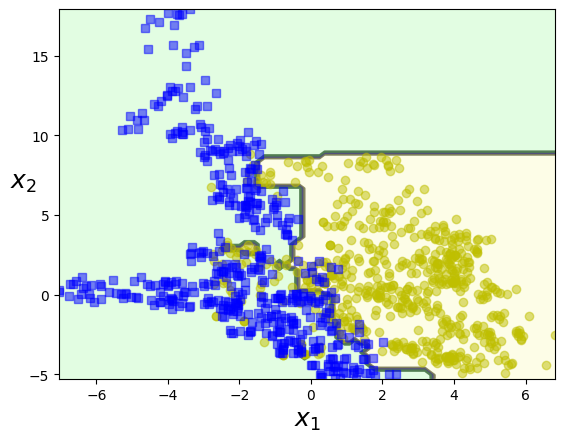

In [28]:
plot_decision_boundary(rnd_clf, X_train, y_train, alpha=0.5, contour=True)

In [29]:
rnd_clf.feature_importances_

array([0.74902151, 0.25097849])

En el modelo Random Forest, la importancia de las variables muestra que Variance es la característica más relevante para la clasificación, con una importancia aproximada de 0.7490, lo que representa el 74.90% de la contribución total. Por su parte, Curtosis presenta una importancia de 0.2510, equivalente al 25.10%. Esto indica que el modelo basa principalmente sus decisiones en la varianza de la imagen transformada, aunque la curtosis también aporta información útil para distinguir entre billetes auténticos y falsificados.

In [30]:
#Cargar librerias
from sklearn.ensemble import GradientBoostingClassifier

# crear objeto de la clase BaggingClassifier
gb_clf = GradientBoostingClassifier(n_estimators = 500,random_state = 2026)

gb_clf.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [31]:
#Obtener el accuracy_score
y_pred_gb= gb_clf.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("El accuracy score que se tiene es %s" %accuracy_gb)

El accuracy score que se tiene es 0.8690909090909091


Text(50.722222222222214, 0.5, 'Real')

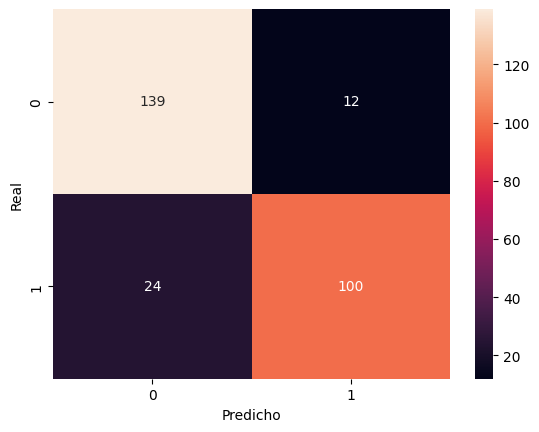

In [32]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb, recall_gb,f1_gb]})
metricas

,Métricas,Valores
0,Precisión,0.892857
1,Recall,0.806452
2,F1,0.847458


El modelo Gradient Boosting con parámetros por defecto obtuvo un accuracy de 0.8691, clasificando correctamente el 86.91% de los billetes del conjunto de validación. Para la clase 1, correspondiente a billetes falsificados, se obtuvo una precisión de 0.8929, un recall de 0.8065 y un F1-score de 0.8475. Estos resultados muestran que el modelo tiene una alta precisión al clasificar billetes como falsificados; sin embargo, su recall es menor que el obtenido por bagging, pasting y Random Forest. Esto indica que, aunque comete pocos falsos positivos, deja sin detectar una mayor proporción de billetes falsificados en comparación con los otros métodos de ensambl

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names


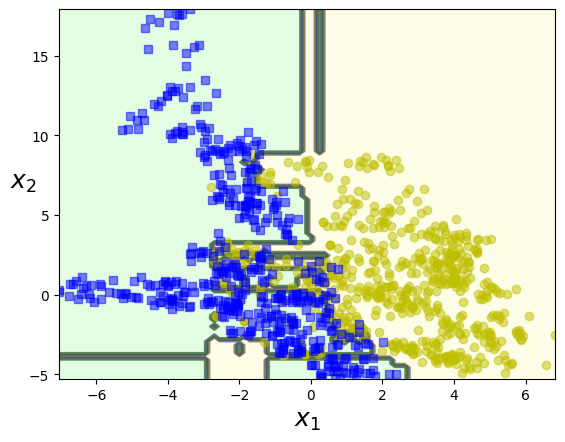

In [34]:
plot_decision_boundary(gb_clf, X_train, y_train, alpha=0.5, contour=True)

Ahora vamos a ajustar los hiperparámetros
del ensamble para obtener un mejor resultado en la predicción. En concreto se van a
probar distintos valores de learning_rate (dejando fijo n_estimators) y de max_depth

In [35]:
#Crear un conjunto de posibles valores
learning_rates = [1, 0.5, 0.25, 0.1, 0.05, 0.01]
max_depths = [1, 2, 3, 4]

#Inicializamos los vectores de resultados
resultados_test = list()
#Bucle para extraer resultados
for eta in learning_rates:
    for d in max_depths:
        gb_clf_i = GradientBoostingClassifier(learning_rate = eta, n_estimators = 500, random_state = 2026, max_depth = d);
        #Entrenamos al modelo
        gb_clf_i.fit(X_train, y_train);
        #Prediccion sobre la muestra de validacion
        y_pred_test = gb_clf_i.predict(X_test);
        #Accuracy de entrenamiento
        acc_test = accuracy_score(y_test, y_pred_test);
        #Guardar resultados en el vector
        resultados_test.append(acc_test);

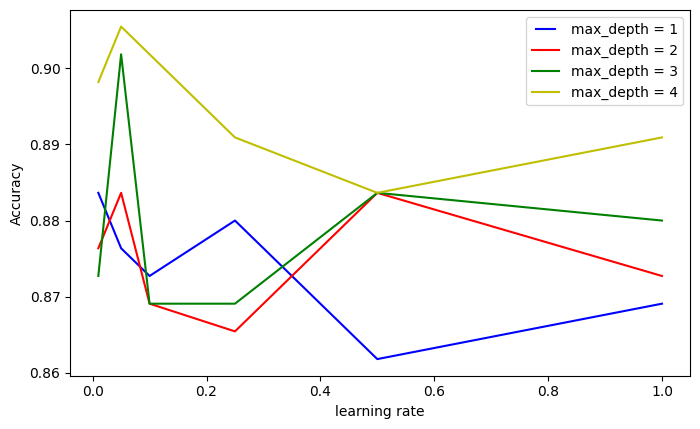

In [36]:
#Resultados_test[0:6] # max_depth = 1
#Resultados_test[6:12] # max_depth = 2
#Resultados_test[12:18] # max_depth = 3
#Resultados_test[18:24] # max_depth = 4

#Learning_rates
# pintamos los resultados de entrenamiento y validacion
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
plt.figure(figsize=(8, 4.75))
line1, = plt.plot(learning_rates, resultados_test[0:6], "b",
label = "max_depth = 1")
line2, = plt.plot(learning_rates, resultados_test[6:12], "r",
label = "max_depth = 2")
line2, = plt.plot(learning_rates, resultados_test[12:18], "g",
label = "max_depth = 3")
line2, = plt.plot(learning_rates, resultados_test[18:24], "y",
label = "max_depth = 4")
plt.legend(handler_map={line1: HandlerLine2D(numpoints = 4)})
plt.ylabel("Accuracy")
plt.xlabel("learning rate")
plt.show()

In [37]:
#Crear mejor modelo
gb_clf_b = GradientBoostingClassifier(learning_rate = 0.05, n_estimators = 500, random_state = 2026, max_depth = 4)
gb_clf_b.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [38]:
#Obtener el accuracy_score
y_pred_gb_b= gb_clf_b.predict(X_test)
accuracy_gb_b = accuracy_score(y_test, y_pred_gb_b)
print("El accuracy score que se tiene es %s" %accuracy_gb_b)

El accuracy score que se tiene es 0.8836363636363637


Text(50.722222222222214, 0.5, 'Real')

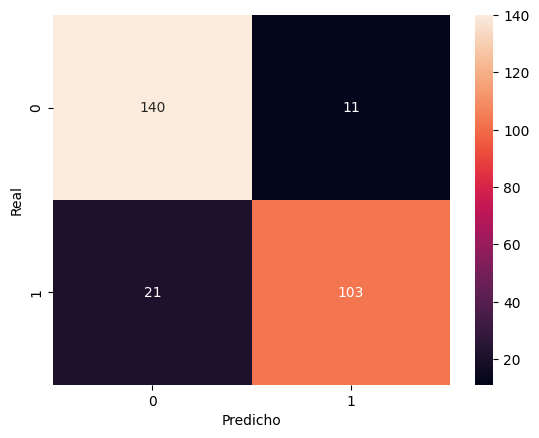

In [39]:
#Obtener la matriz de confusión
cm = confusion_matrix(y_test, y_pred_gb_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_gb = precision_score(y_test, y_pred_gb_b)
recall_gb = recall_score(y_test, y_pred_gb_b)
f1_gb = f1_score(y_test, y_pred_gb_b)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_gb, recall_gb,f1_gb]})
metricas

,Métricas,Valores
0,Precisión,0.903509
1,Recall,0.830645
2,F1,0.865546


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names


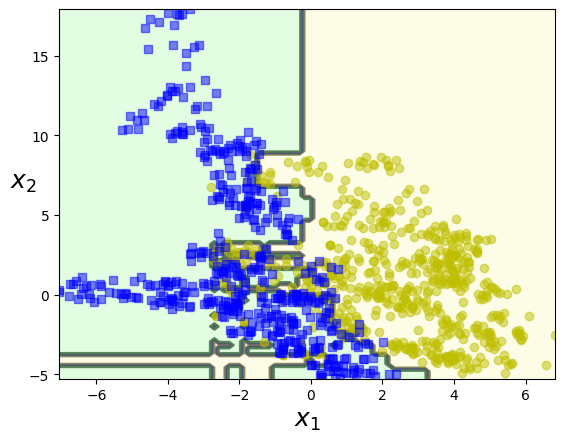

In [41]:
plot_decision_boundary(gb_clf_b, X_train, y_train, alpha=0.5, contour=True)

Al ajustar los hiperparámetros del modelo Gradient Boosting, se obtuvo como mejor combinación un learning_rate de 0.05 y una profundidad máxima max_depth igual a 4. Con esta configuración, el modelo alcanzó un accuracy de 0.8836, clasificando correctamente el 88.36% de los billetes del conjunto de validación. Para la clase 1, correspondiente a billetes falsificados, se obtuvo una precisión de 0.9035, un recall de 0.8306 y un F1-score de 0.8655. Estos resultados muestran una mejora respecto al Gradient Boosting con parámetros por defecto, especialmente en la precisión, el recall y el F1-score. Por tanto, el ajuste de hiperparámetros permitió obtener un modelo más equilibrado y con mayor capacidad predictiva para detectar billetes falsificados.

| Modelo | Accuracy | Precisión | Recall | F1-score |
|---|---:|---:|---:|---:|
| Árbol de decisión | 0.8473 | 0.8868 | 0.7581 | 0.8174 |
| Bagging | 0.8982 | 0.8750 | 0.9032 | 0.8889 |
| Pasting | 0.8982 | 0.8750 | 0.9032 | 0.8889 |
| Random Forest | 0.9055 | 0.8889 | 0.9032 | 0.8960 |
| Gradient Boosting por defecto | 0.8691 | 0.8929 | 0.8065 | 0.8475 |
| Gradient Boosting ajustado | 0.8836 | 0.9035 | 0.8306 | 0.8655 |
|

Al comparar los modelos implementados, se observa que el mejor desempeño general lo obtuvo el modelo Random Forest, con un accuracy de 0.9055 y un F1-score de 0.8960. Además, este modelo mantuvo un recall alto de 0.9032 para la clase 1, correspondiente a billetes falsificados.

Los modelos de Bagging y Pasting también presentaron un buen rendimiento, con métricas idénticas y un recall igualmente alto de 0.9032. Por otro lado, el modelo Gradient Boosting ajustado mejoró respecto al Gradient Boosting con parámetros por defecto, aunque no superó a Random Forest.

En consecuencia, para este problema de clasificación, el modelo Random Forest resulta ser la alternativa más adecuada entre los modelos evaluados.
